# Лабораторная работа №3
## Спектральные признаки и оценка качества аудио

**Тип представления:** Мел-спектрограмма  
**Признаки (своя реализация):** MFCC, спектральная ширина  
**Признаки (библиотеки):** Спектральный центроид, спад, ZCR  
**Метрики (своя реализация):** SNR, SDR  
**Метрики (библиотеки):** PESQ, NISQA, DNSMOS  
**Модель шумоподавления:** MossFormer2  
**Диапазон SNR:** 3-18 дБ, шаг 3 дБ

## Импорт библиотек

In [3]:
import os
import sys
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import librosa.display
from pesq import pesq
import torch
import warnings
import soundfile as sf
import IPython.display as ipd

# Корректные импорты из torchmetrics
from torchmetrics.audio import (
    SignalNoiseRatio,                           # SNR
    SignalDistortionRatio,                      # SDR
    ScaleInvariantSignalDistortionRatio,        # SI-SDR
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Импорт выполнен успешно")

ModuleNotFoundError: No module named 'torchmetrics'

## Пункт 2: Реализация мел-спектрограммы

### 2.1 Собственная реализация мел-спектрограммы

In [ ]:
def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0, fmax=None):
    """
    Создание мел-фильтров для преобразования спектрограммы в мел-спектрограмму.
    """
    if fmax is None:
        fmax = sr / 2
    
    def hz_to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)
    
    def mel_to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)
    
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bin_points = np.floor(hz_points * (n_fft / sr)).astype(int)
    
    mel_basis = np.zeros((n_mels, n_fft // 2 + 1))
    for i in range(n_mels):
        left = bin_points[i]
        center = bin_points[i + 1]
        right = bin_points[i + 2]
        for k in range(left, center):
            if center - left > 0:
                mel_basis[i, k] = (k - left) / (center - left)
        for k in range(center, min(right, n_fft // 2 + 1)):
            if right - center > 0:
                mel_basis[i, k] = (right - k) / (right - center)
    
    return mel_basis


def compute_mel_spectrogram_custom(audio, sr, n_fft=2048, hop_length=512, n_mels=128):
    """
    Вычисление мел-спектрограммы в соответствии с методичкой.
    """
    _, _, Zxx = signal.stft(audio, fs=sr, nperseg=n_fft,
                            noverlap=n_fft-hop_length, window='hann')
    magnitude = np.abs(Zxx)
    mel_basis = create_mel_filterbank(sr, n_fft, n_mels)

    # Энергия в каждом мел-фильтре
    mel_energy = np.dot(mel_basis, magnitude ** 2)

    # Логарифмирование по формуле (46) из методички
    eps = 1e-10
    mel_spec_log = np.log(mel_energy + eps)  # натуральный логарифм

    return mel_spec_log

### 2.2 Загрузка тестовых файлов

In [ ]:
song_files = ['songs/1.wav', 'songs/2.wav', 'songs/3.wav', 'songs/4.wav']
audio_files = {}
for i, file_path in enumerate(song_files):
    y, sr = librosa.load(file_path, sr=None)
    audio_files[f'song_{i+1}'] = {'audio': y, 'sr': sr, 'path': file_path}
    print(f"Загружен {file_path}: {len(y)/sr:.2f} сек, sr={sr} Гц")

### 2.3 Сравнение мел-спектрограмм: своя vs librosa для всех 4 файлов

NameError: name 'audio_files' is not defined

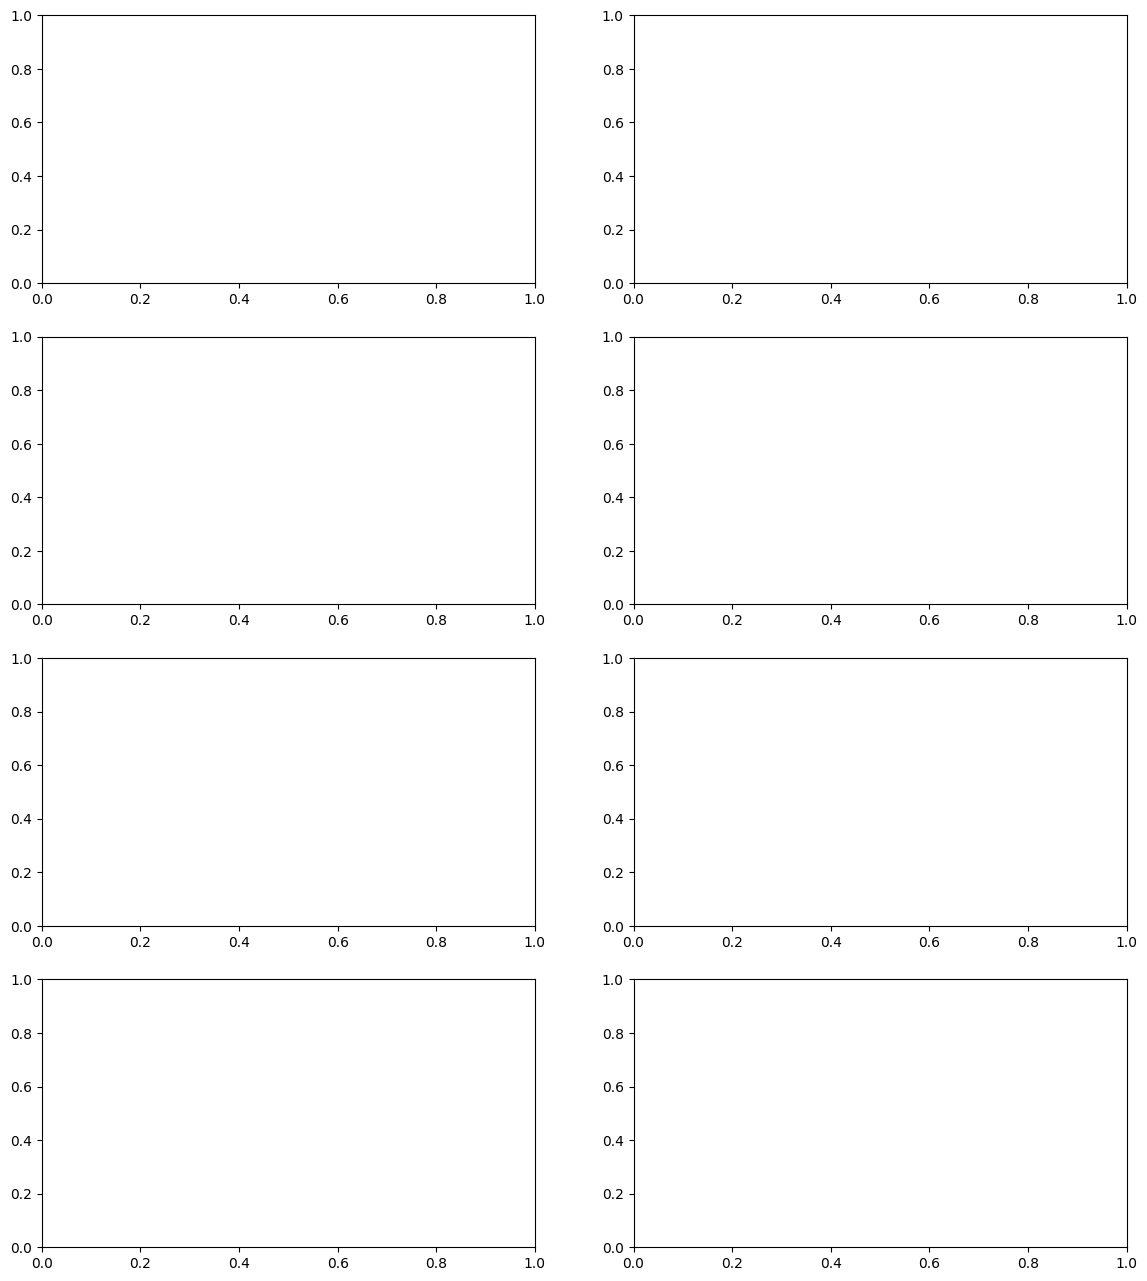

In [4]:
n_fft = 2048
hop_length = 512
n_mels = 128

# Визуализация сравнения для всех 4 файлов
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for idx, (name, data) in enumerate(audio_files.items()):
    audio = data['audio']
    sr = data['sr']
    
    # Своя реализация
    mel_spec_custom = compute_mel_spectrogram_custom(audio, sr, n_fft, hop_length, n_mels)
    
    # Librosa
    mel_spec_librosa = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    mel_spec_librosa_db = librosa.power_to_db(mel_spec_librosa, ref=np.max)
    
    # Обрезаем до одинакового размера
    min_frames = min(mel_spec_custom.shape[1], mel_spec_librosa_db.shape[1])
    mel_spec_custom = mel_spec_custom[:, :min_frames]
    mel_spec_librosa_db = mel_spec_librosa_db[:, :min_frames]
    
    # Слева - своя реализация
    img1 = librosa.display.specshow(mel_spec_custom, x_axis='time', y_axis='mel', sr=sr, hop_length=hop_length, ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{name}: Своя реализация')
    plt.colorbar(img1, ax=axes[idx, 0])
    
    # Справа - librosa
    img2 = librosa.display.specshow(mel_spec_librosa_db, x_axis='time', y_axis='mel', sr=sr, hop_length=hop_length, ax=axes[idx, 1])
    axes[idx, 1].set_title(f'{name}: librosa')
    plt.colorbar(img2, ax=axes[idx, 1])

plt.tight_layout()
plt.show()
print("Мел-спектрограммы для всех 4 файлов: слева - своя реализация, справа - librosa")

**Объяснение:** Мел-спектрограмма преобразует частотную ось в мел-шкалу, которая приближает восприятие частоты человеческим ухом (выше разрешение на низких частотах, ниже на высоких).

## Пункт 3: Спектральные признаки

### 3.1 Собственная реализация MFCC

In [ ]:
def compute_mfcc_custom(audio, sr, n_fft=2048, hop_length=512, n_mels=128, n_mfcc=13):
    """
    MFCC по алгоритму из методички:
    1. STFT → периодограмма
    2. Мел-фильтры
    3. Логарифмирование
    4. DCT
    """
    # Шаг 1: STFT и периодограмма
    _, _, Zxx = signal.stft(audio, fs=sr, nperseg=n_fft,
                            noverlap=n_fft-hop_length, window='hann')
    # Периодограмма P(j,k) = |X(j,k)|^2 / N
    periodogram = np.abs(Zxx) ** 2 / n_fft

    # Шаг 2: Мел-фильтры (из предыдущей реализации)
    mel_basis = create_mel_filterbank(sr, n_fft, n_mels)

    # Шаг 3: Энергии в мел-фильтрах и логарифмирование (натуральный логарифм!)
    mel_energies = np.dot(mel_basis, periodogram)
    log_mel_energies = np.log(mel_energies + 1e-10)  # формула (46) из методички

    # Шаг 4: DCT для получения MFCC
    n_frames = log_mel_energies.shape[1]
    mfcc = np.zeros((n_mfcc, n_frames))

    for k in range(n_mfcc):
        for m in range(n_mels):
            # Формула из методички: cos(π * n * (m + 1/2) / M)
            mfcc[k, :] += log_mel_energies[m, :] * np.cos(np.pi * k * (m + 0.5) / n_mels)
        mfcc[k, :] *= np.sqrt(2 / n_mels)

    # Нормализация первого коэффициента
    mfcc[0, :] *= 1 / np.sqrt(2)

    return mfcc

### 3.2 Собственная реализация спектральной ширины

In [ ]:
def compute_spectral_bandwidth_custom(audio, sr, n_fft=2048, hop_length=512, p=2):
    _, _, Zxx = signal.stft(audio, fs=sr, nperseg=n_fft,
                            noverlap=n_fft-hop_length, window='hann')
    power = np.abs(Zxx) ** 2  # энергия, а не амплитуда
    freqs = np.linspace(0, sr/2, n_fft//2 + 1)

    # Спектральный центроид
    centroid = np.sum(freqs[:, np.newaxis] * power, axis=0) / np.sum(power, axis=0)

    # Спектральная ширина
    numerator = np.sum(power * (freqs[:, np.newaxis] - centroid) ** p, axis=0)
    denominator = np.sum(power, axis=0)
    bandwidth = (numerator / np.maximum(denominator, 1e-10)) ** (1/p)

    return bandwidth

### 3.3 Вычисление признаков для всех файлов

In [ ]:
n_fft = 2048
hop_length = 512
n_mels = 128
n_mfcc = 13

# ========== ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ ВСЕХ ФАЙЛОВ ==========
features_custom = {}  # Свои реализации (MFCC, спектральная ширина)
features_lib = {}     # Библиотечные реализации (все признаки)

for name, data in audio_files.items():
    audio = data['audio']
    sr = data['sr']

    print(f"Обработка: {name}")

    # === СВОИ РЕАЛИЗАЦИИ ===
    mfcc_custom = compute_mfcc_custom(audio, sr, n_fft, hop_length, n_mels, n_mfcc)
    bandwidth_custom = compute_spectral_bandwidth_custom(audio, sr, n_fft, hop_length)

    features_custom[name] = {
        'mfcc': mfcc_custom,
        'bandwidth': bandwidth_custom
    }

    # === БИБЛИОТЕЧНЫЕ РЕАЛИЗАЦИИ ===
    # MFCC (для сравнения)
    mfcc_lib = librosa.feature.mfcc(y=audio, sr=sr, n_fft=n_fft,
                                     hop_length=hop_length, n_mfcc=n_mfcc)

    # Спектральная ширина (для сравнения)
    bandwidth_lib = librosa.feature.spectral_bandwidth(y=audio, sr=sr,
                                                        n_fft=n_fft,
                                                        hop_length=hop_length).flatten()

    # Спектральный центроид
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr,
                                                   n_fft=n_fft,
                                                   hop_length=hop_length).flatten()

    # Спектральный спад (85% энергии)
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr,
                                                n_fft=n_fft,
                                                hop_length=hop_length,
                                                roll_percent=0.85).flatten()

    # Частота пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y=audio,
                                               frame_length=n_fft,
                                               hop_length=hop_length).flatten()

    features_lib[name] = {
        'mfcc': mfcc_lib,
        'bandwidth': bandwidth_lib,
        'centroid': centroid,
        'rolloff': rolloff,
        'zcr': zcr
    }

print("\nГотово! Все признаки извлечены.")

### 3.4 Визуализация признаков

In [ ]:
# ========== СРАВНЕНИЕ MFCC ==========
n_files = len(audio_files)
fig, axes = plt.subplots(n_files, 2, figsize=(14, 4 * n_files))

if n_files == 1:
    axes = np.array([axes]).reshape(1, 2)

for idx, (name, data) in enumerate(audio_files.items()):
    sr = data['sr']

    # Своя реализация
    mfcc_custom = features_custom[name]['mfcc']

    # Библиотечная реализация
    mfcc_lib = features_lib[name]['mfcc']

    # Обрезаем до одинакового количества кадров
    min_frames = min(mfcc_custom.shape[1], mfcc_lib.shape[1])
    mfcc_custom_trim = mfcc_custom[:, :min_frames]
    mfcc_lib_trim = mfcc_lib[:, :min_frames]

    # Визуализация своей реализации
    im1 = axes[idx, 0].imshow(mfcc_custom_trim, aspect='auto', origin='lower', cmap='coolwarm')
    axes[idx, 0].set_title(f'{name} - MFCC (своя реализация)', fontsize=10)
    axes[idx, 0].set_ylabel('MFCC коэффициент', fontsize=9)
    axes[idx, 0].set_xlabel('Кадр', fontsize=9)
    plt.colorbar(im1, ax=axes[idx, 0], label='Значение MFCC')

    # Визуализация библиотечной реализации
    im2 = axes[idx, 1].imshow(mfcc_lib_trim, aspect='auto', origin='lower', cmap='coolwarm')
    axes[idx, 1].set_title(f'{name} - MFCC (librosa)', fontsize=10)
    axes[idx, 1].set_ylabel('MFCC коэффициент', fontsize=9)
    axes[idx, 1].set_xlabel('Кадр', fontsize=9)
    plt.colorbar(im2, ax=axes[idx, 1], label='Значение MFCC')

plt.suptitle('Сравнение MFCC: собственная реализация vs LibROSA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ========== СРАВНЕНИЕ СПЕКТРАЛЬНОЙ ШИРИНЫ ==========
n_files = len(audio_files)
fig, axes = plt.subplots(n_files, 1, figsize=(12, 4 * n_files))

if n_files == 1:
    axes = [axes]

for idx, (name, data) in enumerate(audio_files.items()):
    sr = data['sr']

    # Своя реализация
    bandwidth_custom = features_custom[name]['bandwidth']

    # Библиотечная реализация
    bandwidth_lib = features_lib[name]['bandwidth']

    # Временная ось
    times = np.arange(len(bandwidth_custom)) * hop_length / sr

    # Обрезаем до одинаковой длины
    min_len = min(len(bandwidth_custom), len(bandwidth_lib))
    times = times[:min_len]
    bandwidth_custom = bandwidth_custom[:min_len]
    bandwidth_lib = bandwidth_lib[:min_len]

    # Построение графиков
    axes[idx].plot(times, bandwidth_custom, label='Своя реализация', linewidth=2, alpha=0.8)
    axes[idx].plot(times, bandwidth_lib, label='LibROSA', linewidth=2, alpha=0.8)
    axes[idx].set_title(f'{name} - Спектральная ширина', fontsize=12)
    axes[idx].set_xlabel('Время (с)', fontsize=10)
    axes[idx].set_ylabel('Частота (Гц)', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Сравнение спектральной ширины: собственная реализация vs LibROSA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ========== СПЕКТРАЛЬНЫЙ ЦЕНТРОИД (LibROSA) ==========
n_files = len(audio_files)
fig, axes = plt.subplots(n_files, 1, figsize=(12, 4 * n_files))

if n_files == 1:
    axes = [axes]

for idx, (name, data) in enumerate(audio_files.items()):
    sr = data['sr']

    # Библиотечная реализация
    centroid = features_lib[name]['centroid']

    # Временная ось
    times = np.arange(len(centroid)) * hop_length / sr

    # Построение графика
    axes[idx].fill_between(times, centroid, alpha=0.5, color='steelblue')
    axes[idx].plot(times, centroid, linewidth=1.5, color='darkblue', alpha=0.8)
    axes[idx].set_title(f'{name} - Спектральный центроид', fontsize=12)
    axes[idx].set_xlabel('Время (с)', fontsize=10)
    axes[idx].set_ylabel('Частота (Гц)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Спектральный центроид (LibROSA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ========== СПЕКТРАЛЬНЫЙ СПАД (LibROSA) ==========
n_files = len(audio_files)
fig, axes = plt.subplots(n_files, 1, figsize=(12, 4 * n_files))

if n_files == 1:
    axes = [axes]

for idx, (name, data) in enumerate(audio_files.items()):
    sr = data['sr']

    # Библиотечная реализация
    rolloff = features_lib[name]['rolloff']

    # Временная ось
    times = np.arange(len(rolloff)) * hop_length / sr

    # Построение графика
    axes[idx].fill_between(times, rolloff, alpha=0.5, color='coral')
    axes[idx].plot(times, rolloff, linewidth=1.5, color='darkred', alpha=0.8)
    axes[idx].set_title(f'{name} - Спектральный спад (85% энергии)', fontsize=12)
    axes[idx].set_xlabel('Время (с)', fontsize=10)
    axes[idx].set_ylabel('Частота (Гц)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Спектральный спад (LibROSA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ========== ЧАСТОТА ПЕРЕСЕЧЕНИЯ НУЛЯ (LibROSA) ==========
n_files = len(audio_files)
fig, axes = plt.subplots(n_files, 1, figsize=(12, 4 * n_files))

if n_files == 1:
    axes = [axes]

for idx, (name, data) in enumerate(audio_files.items()):
    sr = data['sr']

    # Библиотечная реализация
    zcr = features_lib[name]['zcr']

    # Временная ось
    times = np.arange(len(zcr)) * hop_length / sr

    # Построение графика
    axes[idx].fill_between(times, zcr, alpha=0.5, color='seagreen')
    axes[idx].plot(times, zcr, linewidth=1.5, color='darkgreen', alpha=0.8)
    axes[idx].set_title(f'{name} - Частота пересечения нуля (ZCR)', fontsize=12)
    axes[idx].set_xlabel('Время (с)', fontsize=10)
    axes[idx].set_ylabel('ZCR', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Частота пересечения нуля (LibROSA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
def add_noise_at_snr(clean_audio, noise_audio, target_snr_db):

    # Обрезаем до одинаковой длины
    min_len = min(len(clean_audio), len(noise_audio))
    clean = clean_audio[:min_len].copy()
    noise = noise_audio[:min_len].copy()

    # Мощности сигналов
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    # Вычисляем требуемую мощность шума
    target_noise_power = signal_power / (10 ** (target_snr_db / 10))

    # Масштабируем шум
    if noise_power > 1e-10:
        scaling_factor = np.sqrt(target_noise_power / noise_power)
        noise_scaled = noise * scaling_factor
    else:
        noise_scaled = noise

    # Смешиваем
    noisy = clean + noise_scaled

    # Проверка: вычисляем фактическое SNR после смешивания
    actual_noise_power = np.mean((noisy - clean) ** 2)
    if actual_noise_power > 1e-10:
        actual_snr = 10 * np.log10(signal_power / actual_noise_power)
        print(f"    Целевое SNR: {target_snr_db} dB, фактическое: {actual_snr:.2f} dB")

    return noisy

def generate_snr_range(clean_audio, noise_audio, snr_min, snr_max, snr_step):
    """Генерирует зашумленные сигналы для диапазона SNR"""
    signals = {}
    for snr_db in range(snr_min, snr_max + 1, snr_step):
        noisy_audio = add_noise_at_snr(clean_audio, noise_audio, snr_db)
        signals[snr_db] = {'audio': noisy_audio, 'target_snr': snr_db}
    return signals

In [ ]:
voice_files = ['voices/gleb.wav', 'voices/Margarita.wav']
voice_data = {}

for file_path in voice_files:
    y, sr = librosa.load(file_path, sr=None)
    name = file_path.split('/')[-1].replace('.wav', '')
    voice_data[name] = {'audio': y, 'sr': sr, 'path': file_path}
    print(f"Загружен {file_path}: {len(y)/sr:.2f} сек, частота {sr} Гц")

# Генерация белого шума
max_len = max(v['audio'].shape[0] for v in voice_data.values())
np.random.seed(42)
white_noise = np.random.randn(max_len) * 0.1  # амплитуда 0.1 для начального уровня
print(f"Сгенерирован белый шум: {len(white_noise)} сэмплов")

In [ ]:
SNR_MIN, SNR_MAX, SNR_STEP = 3, 18, 3
noisy_voice_data = {}

for name, data in voice_data.items():
    clean = data['audio']
    sr = data['sr']
    signals = generate_snr_range(clean, white_noise, SNR_MIN, SNR_MAX, SNR_STEP)
    noisy_voice_data[name] = {
        'clean': clean,
        'sr': sr,
        'noisy_signals': signals
    }

In [ ]:
def plot_noisy_signals(voice_name, voice_data, sample_rate, duration=1.0):

    clean = voice_data['clean']
    signals = voice_data['noisy_signals']

    # Обрезаем до нужной длительности
    samples_to_show = int(duration * sample_rate)
    samples_to_show = min(samples_to_show, len(clean))

    clean_trim = clean[:samples_to_show]
    times = np.arange(samples_to_show) / sample_rate

    # Сортируем SNR
    snr_values = sorted(signals.keys())
    n_signals = len(snr_values)

    fig, axes = plt.subplots(n_signals + 1, 1, figsize=(12, 3 * (n_signals + 1)))

    # Чистый сигнал
    axes[0].plot(times, clean_trim, linewidth=0.8, color='blue')
    axes[0].set_title(f'{voice_name} - Чистый сигнал', fontsize=12)
    axes[0].set_ylabel('Амплитуда')
    axes[0].set_xlim(0, duration)
    axes[0].grid(True, alpha=0.3)

    # Сигналы с шумом
    for idx, snr in enumerate(snr_values):
        noisy = signals[snr]['audio'][:samples_to_show]
        axes[idx + 1].plot(times, noisy, linewidth=0.8, color='red', alpha=0.7)
        axes[idx + 1].set_title(f'{voice_name} - SNR = {snr} дБ', fontsize=12)
        axes[idx + 1].set_ylabel('Амплитуда')
        axes[idx + 1].set_xlim(0, duration)
        axes[idx + 1].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Время (с)', fontsize=10)
    plt.tight_layout()
    plt.show()


# ========== ПРОСЛУШИВАНИЕ РЕЗУЛЬТАТОВ ==========
def listen_to_signals(voice_name, voice_data, sample_rate):
    """
    Вывод аудиоплееров для прослушивания.
    """
    print(f"\n{'='*50}")
    print(f"Прослушивание: {voice_name}")
    print(f"{'='*50}")

    # Чистый сигнал
    print(f"\nЧистый голос:")
    display(ipd.Audio(voice_data['clean'], rate=sample_rate))

    # Сигналы с шумом
    for snr in sorted(voice_data['noisy_signals'].keys()):
        print(f"\nSNR = {snr} дБ:")
        display(ipd.Audio(voice_data['noisy_signals'][snr]['audio'], rate=sample_rate))


# ========== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ==========
def save_noisy_signals(voice_name, voice_data, output_dir='noisy_voices'):
    """
    Сохраняет сгенерированные сигналы в файлы.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    sr = voice_data['sr']

    # Сохраняем чистый сигнал
    clean_path = f"{output_dir}/{voice_name}_clean.wav"
    sf.write(clean_path, voice_data['clean'], sr)
    print(f"Сохранен: {clean_path}")

    # Сохраняем сигналы с шумом
    for snr, signal_info in voice_data['noisy_signals'].items():
        noisy_path = f"{output_dir}/{voice_name}_snr_{snr}db.wav"
        sf.write(noisy_path, signal_info['audio'], sr)
        print(f"Сохранен: {noisy_path}")


for name, data in noisy_voice_data.items():
    plot_noisy_signals(name, data, data['sr'], duration=2.0)


for name, data in noisy_voice_data.items():
    listen_to_signals(name, data, data['sr'])

In [ ]:
def compute_snr_custom(clean, noisy):
    """
    Отношение сигнал/шум (SNR) по формуле (48) из методички.
    """
    min_len = min(len(clean), len(noisy))
    clean = clean[:min_len]
    noisy = noisy[:min_len]

    signal_power = np.mean(clean ** 2)
    noise = noisy - clean
    noise_power = np.mean(noise ** 2)

    if noise_power == 0:
        return float('inf')

    return 10 * np.log10(signal_power / noise_power)


def compute_sdr_custom(clean, estimated):
    """
    Отношение сигнал/искажение (SDR) по формуле (51) из методички.
    """
    min_len = min(len(clean), len(estimated))
    clean = clean[:min_len]
    estimated = estimated[:min_len]

    signal_power = np.mean(clean ** 2)
    distortion = clean - estimated
    distortion_power = np.mean(distortion ** 2)

    if distortion_power == 0:
        return float('inf')

    return 10 * np.log10(signal_power / distortion_power)

In [ ]:
def compute_all_metrics(clean, processed, original_sr):
    """
    Вычисляет все метрики качества.
    """
    # Обрезаем до одинаковой длины
    min_len = min(len(clean), len(processed))
    clean = clean[:min_len]
    processed = processed[:min_len]

    # Приводим к 1D массиву, если нужно
    if isinstance(processed, np.ndarray):
        if processed.ndim == 2:
            processed = processed.squeeze()
        if processed.ndim > 2:
            processed = processed.flatten()

    # Конвертируем в тензоры PyTorch
    clean_t = torch.from_numpy(clean).float()
    processed_t = torch.from_numpy(processed).float()

    # Добавляем batch dimension для метрик
    if clean_t.dim() == 1:
        clean_t = clean_t.unsqueeze(0)
    if processed_t.dim() == 1:
        processed_t = processed_t.unsqueeze(0)

    # --- ПРОСТЫЕ МЕТРИКИ (SNR, SDR, SI-SDR) ---
    snr_metric = SignalNoiseRatio()
    sdr_metric = SignalDistortionRatio()
    sisdr_metric = ScaleInvariantSignalDistortionRatio()

    try:
        snr_lib = snr_metric(processed_t, clean_t).item()
        sdr_lib = sdr_metric(processed_t, clean_t).item()
        sisdr_lib = sisdr_metric(processed_t, clean_t).item()
    except Exception as e:
        print(f"    Ошибка в простых метриках: {e}")
        snr_lib = sdr_lib = sisdr_lib = float('nan')

    # --- РЕСЕМПЛИНГ ДЛЯ 16 кГц ---
    sr_target = 16000
    if original_sr != sr_target:
        clean_resampled = librosa.resample(clean, orig_sr=original_sr, target_sr=sr_target)
        processed_resampled = librosa.resample(processed, orig_sr=original_sr, target_sr=sr_target)
    else:
        clean_resampled = clean
        processed_resampled = processed

    # Приводим к 1D
    if isinstance(processed_resampled, np.ndarray) and processed_resampled.ndim > 1:
        processed_resampled = processed_resampled.squeeze()

    # PESQ
    try:
        pesq_score = pesq(sr_target, clean_resampled.astype(np.float64),
                         processed_resampled.astype(np.float64), 'wb')
    except Exception as e:
        print(f"    PESQ error: {e}")
        pesq_score = float('nan')

    # NISQA
    try:
        nisqa_metric = NonIntrusiveSpeechQualityAssessment(fs=sr_target)
        nisqa_result = nisqa_metric(preds=torch.from_numpy(processed_resampled).float())
        if isinstance(nisqa_result, torch.Tensor) and nisqa_result.numel() >= 1:
            nisqa_score = nisqa_result[0].item()
        else:
            nisqa_score = float('nan')
    except Exception as e:
        print(f"    NISQA error: {e}")
        nisqa_score = float('nan')

    # DNSMOS
    try:
        dnsmos_metric = DeepNoiseSuppressionMeanOpinionScore(fs=sr_target, personalized=False)
        dnsmos_result = dnsmos_metric(preds=torch.from_numpy(processed_resampled).float())
        if isinstance(dnsmos_result, torch.Tensor) and dnsmos_result.numel() >= 4:
            dnsmos_score = dnsmos_result[3].item()
        else:
            dnsmos_score = float('nan')
    except Exception as e:
        print(f"    DNSMOS error: {e}")
        dnsmos_score = float('nan')

    return {
        'SNR_library_dB': snr_lib,
        'SDR_library_dB': sdr_lib,
        'SI-SDR_library_dB': sisdr_lib,
        'PESQ': pesq_score,
        'NISQA': nisqa_score,
        'DNSMOS': dnsmos_score
    }

In [ ]:
def compute_metrics_for_all_signals(noisy_voice_data):
    """Вычисляет все метрики для каждого голоса и каждого SNR"""
    results = []

    for voice_name, voice_info in noisy_voice_data.items():
        clean_audio = voice_info['clean']
        sr = voice_info['sr']

        print(f"\n{'='*60}")
        print(f"Обработка: {voice_name}")
        print(f"{'='*60}")

        for snr_target, signal_info in sorted(voice_info['noisy_signals'].items()):
            noisy_audio = signal_info['audio']

            print(f"\n--- SNR target = {snr_target} dB ---")

            # Собственные реализации
            snr_custom = compute_snr_custom(clean_audio, noisy_audio)
            sdr_custom = compute_sdr_custom(clean_audio, noisy_audio)

            # Библиотечные метрики
            try:
                other_metrics = compute_all_metrics(clean_audio, noisy_audio, sr)
            except Exception as e:
                print(f"    Ошибка при вычислении метрик: {e}")
                other_metrics = {
                    'SNR_library_dB': float('nan'),
                    'SDR_library_dB': float('nan'),
                    'SI-SDR_library_dB': float('nan'),
                    'PESQ': float('nan'),
                    'NISQA': float('nan'),
                    'DNSMOS': float('nan')
                }

            result = {
                'Voice': voice_name,
                'Target_SNR_dB': snr_target,
                'SNR_custom_dB': snr_custom,
                'SDR_custom_dB': sdr_custom,
                **other_metrics
            }

            results.append(result)

            # Вывод
            print(f"  SNR (custom):   {snr_custom:.2f} dB")
            print(f"  SNR (library):  {other_metrics['SNR_library_dB']:.2f} dB")
            print(f"  SDR (custom):   {sdr_custom:.2f} dB")
            print(f"  SDR (library):  {other_metrics['SDR_library_dB']:.2f} dB")
            print(f"  PESQ:           {other_metrics['PESQ']:.4f}")
            print(f"  NISQA:          {other_metrics['NISQA']:.4f}")
            print(f"  DNSMOS:         {other_metrics['DNSMOS']:.4f}")

    return pd.DataFrame(results)

# Вычисляем все метрики
results_df = compute_metrics_for_all_signals(noisy_voice_data)

# Отображение результатов в виде таблицы
print("\n" + "=" * 120)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА ЗВУКА")
print("=" * 120)

# Настраиваем отображение DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# Выводим таблицу
display(results_df)

In [ ]:
clearvoice = r'C:\Users\Terminus\PycharmProjects\SoSii3\ClearerVoice-Studio\clearvoice'
if clearvoice not in sys.path:
    sys.path.insert(0, clearvoice)

from clearvoice import ClearVoice

myClearVoice = ClearVoice(
    task='speech_enhancement',
    model_names=['MossFormer2_SE_48K']
)

In [ ]:
def denoise_with_mossformer2(noisy_audio, original_sr):
    """
    Обработка аудио через MossFormer2
    """
    temp_dir = 'temp_audio'
    os.makedirs(temp_dir, exist_ok=True)

    input_path = os.path.join(temp_dir, 'input.wav')
    sf.write(input_path, noisy_audio, original_sr)

    try:
        output_wav = myClearVoice(
            input_path=input_path,
            online_write=False
        )

        # Извлекаем очищенное аудио
        if isinstance(output_wav, dict) and 'audio' in output_wav:
            denoised = output_wav['audio']
        else:
            denoised = output_wav

        # Приводим к 1D массиву
        if isinstance(denoised, np.ndarray):
            # Если 2D (например, [1, samples]), сжимаем
            if denoised.ndim == 2:
                denoised = denoised.squeeze()
            # Приводим к float32
            denoised = denoised.astype(np.float32)

        # Обрезаем до исходной длины
        min_len = min(len(denoised), len(noisy_audio))
        return denoised[:min_len]

    except Exception as e:
        print(f"    Ошибка обработки: {e}")
        return noisy_audio
    finally:
        if os.path.exists(input_path):
            os.remove(input_path)

In [ ]:
results_denoised = []

for voice_name, voice_info in noisy_voice_data.items():
    clean_audio = voice_info['clean']
    sr = voice_info['sr']

    print(f"\n{'='*60}")
    print(f"Обработка: {voice_name}")
    print(f"{'='*60}")

    voice_info['denoised_signals'] = {}

    for snr_target, signal_info in sorted(voice_info['noisy_signals'].items()):
        noisy_audio = signal_info['audio']

        print(f"\n--- SNR target = {snr_target} dB ---")

        metrics_before = compute_all_metrics(clean_audio, noisy_audio, sr)
        snr_before = compute_snr_custom(clean_audio, noisy_audio)

        denoised_audio = denoise_with_mossformer2(noisy_audio, sr)

        voice_info['denoised_signals'][snr_target] = denoised_audio

        metrics_after = compute_all_metrics(clean_audio, denoised_audio, sr)
        snr_after = compute_snr_custom(clean_audio, denoised_audio)

        result = {
            'Voice': voice_name,
            'Target_SNR_dB': snr_target,
            'Noisy_SNR_dB': snr_before,
            'Noisy_PESQ': metrics_before['PESQ'],
            'Noisy_NISQA': metrics_before['NISQA'],
            'Noisy_DNSMOS': metrics_before['DNSMOS'],
            'Denoised_SNR_dB': snr_after,
            'Denoised_PESQ': metrics_after['PESQ'],
            'Denoised_NISQA': metrics_after['NISQA'],
            'Denoised_DNSMOS': metrics_after['DNSMOS'],
            'SNR_improvement': snr_after - snr_before,
            'PESQ_improvement': metrics_after['PESQ'] - metrics_before['PESQ']
        }

        results_denoised.append(result)

        print(f"    До: SNR={snr_before:.2f} dB, PESQ={metrics_before['PESQ']:.4f}, DNSMOS={metrics_before['DNSMOS']:.4f}")
        print(f"    После: SNR={snr_after:.2f} dB, PESQ={metrics_after['PESQ']:.4f}, DNSMOS={metrics_after['DNSMOS']:.4f}")
        print(f"    Улучшение: SNR +{snr_after - snr_before:.2f} dB, PESQ +{metrics_after['PESQ'] - metrics_before['PESQ']:.4f}")

results_df = pd.DataFrame(results_denoised)

pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

def listen_to_denoised(voice_name, voice_info, sample_rate, duration=3.0):
    clean = voice_info['clean']
    sr = sample_rate
    samples = int(duration * sr)
    samples = min(samples, len(clean))

    print(f"\nЧистый голос:")
    display(ipd.Audio(clean[:samples], rate=sr))

    for snr in sorted(voice_info['noisy_signals'].keys()):
        if snr in voice_info.get('denoised_signals', {}):
            noisy = voice_info['noisy_signals'][snr]['audio']
            denoised = voice_info['denoised_signals'][snr]

            # Находим метрики
            metrics = results_df[(results_df['Voice'] == voice_name) &
                                 (results_df['Target_SNR_dB'] == snr)].iloc[0]

            print(f"\nSNR = {snr} dB")
            print(f"   До: PESQ={metrics['Noisy_PESQ']:.3f}, DNSMOS={metrics['Noisy_DNSMOS']:.3f}")
            print(f"   После: PESQ={metrics['Denoised_PESQ']:.3f}, DNSMOS={metrics['Denoised_DNSMOS']:.3f}")
            print(f"   Зашумленный сигнал:")
            display(ipd.Audio(noisy[:samples], rate=sr))
            print(f"   Очищенный сигнал (MossFormer2):")
            display(ipd.Audio(denoised[:samples], rate=sr))
            print("-"*50)

for voice_name, voice_info in noisy_voice_data.items():
    listen_to_denoised(voice_name, voice_info, voice_info['sr'], duration=3.0)